In [1]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Load CSV file
df = pd.read_csv('../data/DA task.csv', encoding='latin1')

In [3]:
df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [4]:
df.shape

(170526, 7)

Data Cleaning Process

In [5]:
date_cols = ["TIMESTAMP", "CONVERTED_AT", "TRIAL_START", "TRIAL_END"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

#The above code converts all 4 date columns from text into real dates so we can do date calculations.
#If any value can't be converted it becomes blank (NaT) instead of crashing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ORGANIZATION_ID  170526 non-null  object        
 1   ACTIVITY_NAME    170526 non-null  object        
 2   TIMESTAMP        170526 non-null  datetime64[ns]
 3   CONVERTED        170526 non-null  bool          
 4   CONVERTED_AT     34235 non-null   datetime64[ns]
 5   TRIAL_START      170526 non-null  datetime64[ns]
 6   TRIAL_END        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [7]:
#Removing extra space and organizing our data
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
df.columns

# I just did this for better readability

Index(['organization_id', 'activity_name', 'timestamp', 'converted',
       'converted_at', 'trial_start', 'trial_end'],
      dtype='object')

In [8]:
# Check missing values
print(df.isna().sum())

organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


In [9]:
#Removing Duplicates
before = len(df) # We count the number of rows

In [10]:
df = df.drop_duplicates().reset_index(drop=True).copy()

In [11]:
after = len(df) # We count the number of rows again

In [12]:
print(f"Duplicates removed: {before - after: ,}")

Duplicates removed:  67,631


In [12]:
print(f"Clean shape: {df.shape}")

Clean shape: (102895, 7)


What was done in the above cells was basically to clean our data Counts total rows, removes exact duplicate rows then counts again to see how many were removed. `.reset_index()` reorders row numbers cleanly, and `.copy()` creates a separate fresh dataset.

Feature Engineering

In [13]:
df["days_into_trial"] = (df['timestamp'] - df['trial_start']).dt.days

For every row the above code calculates how many days into the trial that event happened. If an event happened on Day 3 of the trial, days_into_trial = 3. This is done by subtracting the trial start date from the event timestamp. Then i now have a new column called days_into_trial.

In [14]:
df["within_trial"] = (
    (df["timestamp"] >= df["trial_start"]) 
    & (df["timestamp"] <=df["trial_end"])
)

Generates a boolean column for each row indicating whether the event falls inside the 30-day trial period. A value of True shows the event occurred during the trial window, while False indicates it happened either before the trial began or after it ended.

This adds a new column named within_trial.

In [15]:
out_of_Windows = df[~df["within_trial"]]
print(f"Out of trail events: {len(out_of_Windows):,}")

Out of trail events: 0



The above line of code selects only the rows that occurred outside the trial window and counts them. The ~ operator represents NOT, so it filters for rows where within_trial is False

In [16]:
df_clean = df[df["within_trial"]].copy()
print(f"Final clean shape (in_windows only) : {df_clean.shape}")

Final clean shape (in_windows only) : (102895, 9)



This produces the final cleaned dataset by filtering to only include events that occurred during the trial period. All subsequent analysis is based on df_clean.

In [ ]:
print(f"Unique_orgs: {df_clean['organization_id'].nunique():,}")
print(f"Converted_orgs: {df_clean[df_clean['converted']==True]['organization_id'].nunique():,}")
print(f"Non-converted_orgs: {df_clean[df_clean['converted']==False]['organization_id'].nunique():,}")
print(f"\n Data range of events: {df_clean['timestamp'].min()} → {df_clean['timestamp'].max()}")


Unique_orgs: 966
Converted_orgs: 206
Non-converted_orgs: 760

 Data range of events: 2024-01-01 20:52:26 → 2024-04-28 15:10:31


This highlights the final validation checks by identifying the number of unique organizations in the cleaned dataset, counting how many converted versus those that did not, and verifying the overall event date range.

After cleaning the dataset, building a organisation level table follows next, this collapses 102,895 event rows into 966 rows i.e. one row per organisation. Think of it as turning a detailed attendance register into a report card for each student.

In [19]:
# Building Org-Level Summary Table

# But first we need to Count How Many Times Each Org Did An Activity

activity_counts = (
    df_clean.groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)

)

Aggregates the data by organization and activity, counting how often each organization performed each activity. 

This results in a table where each row represents one organization and each column represents an activity.

In [21]:
# I will proceed to build the core organization level metrics

org_stats = (
    df_clean.groupby("organization_id")
    .agg(
        converted = ("converted", "first"),
        converted_at = ("converted_at", "first"),
        trial_start = ("trial_start", "first"),
        trial_end = ("trial_end", "first"),
        total_events = ("activity_name", "count"),
        unique_activities = ("activity_name", "nunique"),
        days_active = ("days_into_trial", "nunique"),
        first_event_day = ("days_into_trial", "min"),
        last_events_day = ("days_into_trial", "max"),
    )
)  

In [22]:
print(org_stats)

                                  converted        converted_at  \
organization_id                                                   
0040dd9ab132b92d5d04bc3acf14d2e2      False                 NaT   
00456fd86311b6095ad05f7e31758f0d      False                 NaT   
007d48a2bc006e6eac0348c788d26dfd      False                 NaT   
00d6461845d0042b929379c263e9edef      False                 NaT   
00d812389a3cffdbf014ba194cbe922e      False                 NaT   
...                                     ...                 ...   
4e44f506184abb41230dca9183e0dfde       True 2024-02-03 15:12:28   
4e76bb8e72c66ac1020407778635938f      False                 NaT   
4e7e4c7bd153b3e8728e7be9e717071b      False                 NaT   
4e900f739ad1a3cc11c0bc2ad85db6ff      False                 NaT   
4eb736e6ff7851d301ae68a6aa37081a      False                 NaT   

                                         trial_start           trial_end  \
organization_id                                     

For each organization, calculates 9 key summary metrics:

converted — whether the organization converted (Yes or No)

converted_at — the date of conversion

trial_start / trial_end — the start and end dates of the trial

total_events — total number of actions performed

unique_activities — number of distinct activities engaged in

days_active — number of days with any recorded activity

first_event_day — how soon activity began after the trial started

last_event_day — how far into the trial they remained active

In [ ]:
org_df = org_stats.join(activity_counts)

#  Combines the two tables: the summary stats and the activity counts side by side into one single table called org_df.

## Derived Fields

In [32]:
#Calculate number of days between each activity and the trial start date
df['days_since_trial_start'] = (df['timestamp'] - df['trial_start']).dt.days

# Trial duration (sanity check)
df['trial_duration'] = (df['trial_end'] - df['trial_start']).dt.days

In [33]:
# Time to conversion
df['time_to_convert'] = (df['converted_at'] - df['trial_start']).dt.days

# Early engagement (first 7 days)
df['is_first_week'] = df['days_since_trial_start'] <= 7

Let get to know our data

In [34]:
print("Minimum Date:", df['timestamp'].min())
print("Maximum Date:", df['timestamp'].max())

print(df['timestamp'].dt.year.value_counts())

Minimum Date: 2024-01-01 20:52:26
Maximum Date: 2024-04-28 15:10:31
timestamp
2024    102895
Name: count, dtype: int64


In [35]:
df['activity_name']
print(df['activity_name'].unique())

['Scheduling.Shift.Created' 'Scheduling.Shift.AssignmentChanged'
 'Communication.Message.Created' 'Mobile.Schedule.Loaded'
 'Absence.Request.Created' 'Absence.Request.Approved'
 'Scheduling.Availability.Set' 'Scheduling.Template.ApplyModal.Applied'
 'PunchClockStartNote.Add.Completed' 'PunchClock.PunchedIn'
 'PunchClock.Entry.Edited' 'Scheduling.Shift.Approved'
 'ShiftDetails.View.Opened' 'Absence.Request.Rejected'
 'Scheduling.OpenShiftRequest.Created' 'Scheduling.ShiftSwap.Created'
 'PunchClockEndNote.Add.Completed' 'PunchClock.PunchedOut'
 'Integration.Xero.PayrollExport.Synced'
 'Timesheets.BulkApprove.Confirmed' 'Scheduling.ShiftHandover.Created'
 'Scheduling.ShiftHandover.Accepted' 'Revenue.Budgets.Created'
 'Break.Activate.Started' 'Break.Activate.Finished' 'Shift.View.Opened'
 'Scheduling.OpenShiftRequest.Approved' 'Scheduling.ShiftSwap.Accepted']


In [36]:
df['converted']
print(df['converted'].unique())

[False  True]


In [37]:
df.columns

Index(['organization_id', 'activity_name', 'timestamp', 'converted',
       'converted_at', 'trial_start', 'trial_end', 'days_into_trial',
       'days_since_trial_start', 'trial_duration', 'time_to_convert',
       'is_first_week'],
      dtype='object')

In [38]:
df['days_since_trial_start']
print(df['days_since_trial_start'].unique())

[ 0 19 21 22 23 24 25 26 27 28 29  1  8  9 10 11 14 15 16 17 18 20  5  6
  7 12 13  3  2  4]


In [39]:
df['time_to_convert']
print(df['time_to_convert'].unique())

[nan 24. 27. 49. 22. 15. 42. 17. 25. 35. 43. 39. 31. 23. 28. 36. 30. 33.
 37. 34. 64. 29. 32. 38. 44. 26. 14. 40. 41. 16. 19. 21. 20. 18. 45. 55.]


In [40]:
df['is_first_week']
print(df['is_first_week'].unique())

[ True False]


### Organization-Level Feature Engineering

To analyze conversion behavior, event-level data was aggregated into organization-level metrics. This allows us to compare engagement patterns between converting and non-converting trialists.

The following features were created:
- Total events: Overall product usage volume
- Active days: Frequency of engagement
- Max active day: Duration of engagement within trial period
- Conversion status: Target variable for analysis

In [41]:
org_df = df.groupby('organization_id').agg({
    'activity_name': 'count',   # total events
    'timestamp': 'nunique',     # active days
    'converted': 'max',         # whether org converted
    'days_since_trial_start': 'max'
}).reset_index()

# Rename columns for clarity and business interpretation
org_df.rename(columns={
    'activity_name': 'total_events',
    'timestamp': 'active_days',
    'days_since_trial_start': 'max_active_day'
}, inplace=True)

org_df.head()

,organization_id,total_events,active_days,converted,max_active_day
0,0040dd9ab132b92d5d04bc3acf14d2e2,1004,997,False,29
1,00456fd86311b6095ad05f7e31758f0d,6,6,False,0
2,007d48a2bc006e6eac0348c788d26dfd,5,5,False,1
3,00d6461845d0042b929379c263e9edef,2,2,False,8
4,00d812389a3cffdbf014ba194cbe922e,586,586,False,29


In [42]:
df.to_csv('clean_dataset_task.csv', index=False)

## Visuals

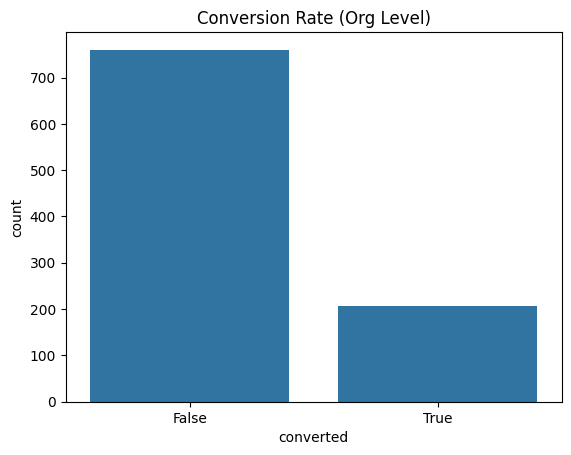

Overall conversion rate: 21.33%


In [43]:
# Conversion Rate
sns.countplot(x='converted', data=org_df)
plt.title("Conversion Rate (Org Level)")
plt.show()

conversion_rate = org_df['converted'].mean()
print(f"Overall conversion rate: {conversion_rate:.2%}")

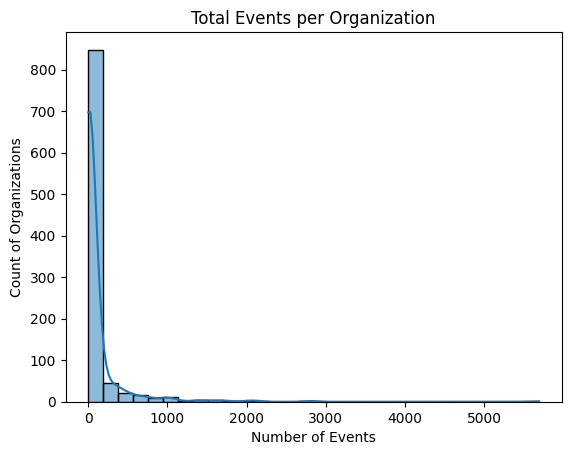

In [44]:
# Distribution of Activity
sns.histplot(org_df['total_events'], bins=30, kde=True)
plt.title("Total Events per Organization")
plt.xlabel("Number of Events")
plt.ylabel("Count of Organizations")
plt.show()

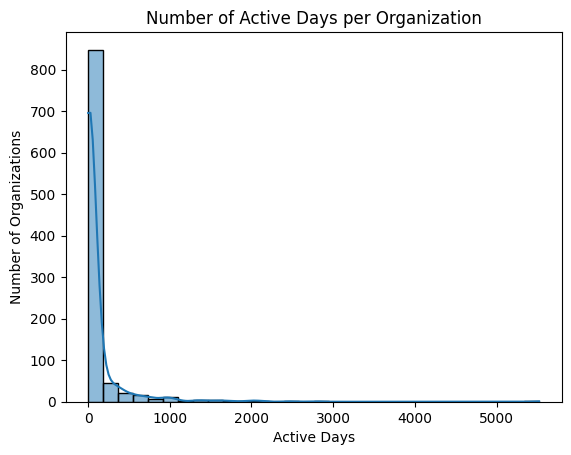

In [45]:
# Active Days Distribution
sns.histplot(org_df['active_days'], bins=30, kde=True)
plt.title("Number of Active Days per Organization")
plt.xlabel("Active Days")
plt.ylabel("Number of Organizations")
plt.show()

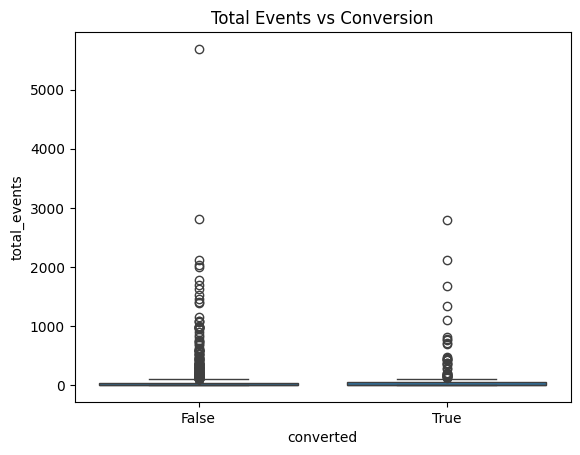

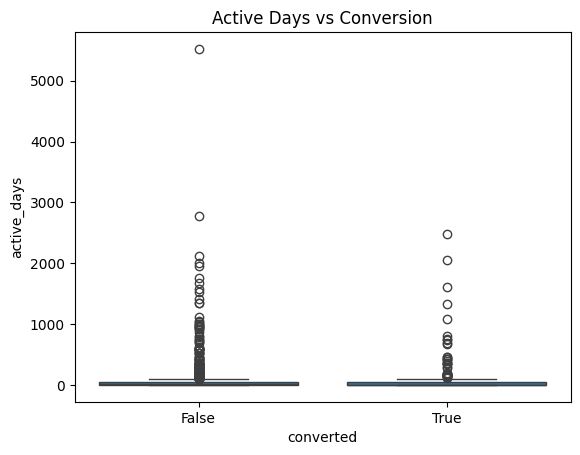

In [46]:
# Events vs Conversion
sns.boxplot(x='converted', y='total_events', data=org_df)
plt.title("Total Events vs Conversion")
plt.show()

sns.boxplot(x='converted', y='active_days', data=org_df)
plt.title("Active Days vs Conversion")
plt.show()

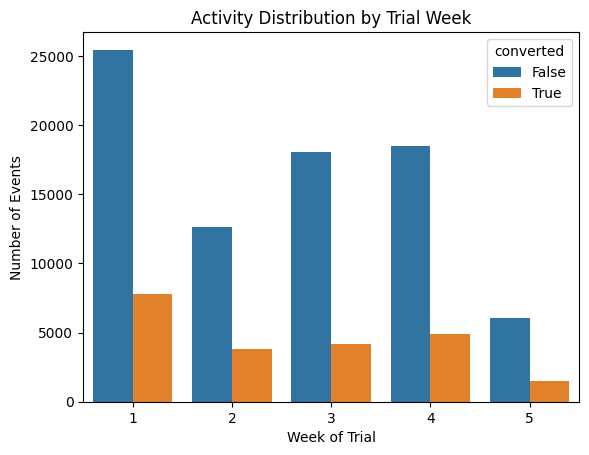

In [47]:
# Timeline of Activity
df['week_of_trial'] = (df['timestamp'] - df['trial_start']).dt.days // 7 + 1
sns.countplot(x='week_of_trial', hue='converted', data=df)
plt.title("Activity Distribution by Trial Week")
plt.xlabel("Week of Trial")
plt.ylabel("Number of Events")
plt.show()

In [48]:
weekly = df.groupby(['week_of_trial', 'converted']).size().unstack()

weekly['conversion_rate'] = weekly[True] / (weekly[True] + weekly[False])

weekly

converted,False,True,conversion_rate
week_of_trial,,,
1,25441,7774,0.234051
2,12615,3788,0.230933
3,18019,4207,0.189283
4,18517,4929,0.210228
5,6080,1525,0.200526


## Summary

Conversion is highest in the first week of the trial at 23.4%, which suggests that early engagement plays a big role in whether an organization converts. There’s a clear drop by Week 3, indicating that users who don’t engage meaningfully early on are less likely to continue toward conversion. This makes the first 7 days especially important for driving key product interactions.